# Leave-One-Unit-Out Evaluation of Performance-Metric RUL Prediction

In [1]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import copy 
import imageio

from src.models.particle_filter.core import ParticleFilter
from src.models.networks.pf_mlp import ParticleFilterMLP
from src.models.rul_predictor import RULPredictor

from src.helpers.visualization import create_rul_prediction_frame,plot_rul_from_dataframe
from src.helpers.seed import set_global_seed

from experiment_config import (
    DATA_NAME,DegModel,SEED,LEAKY_SLOPE,HIDDEN_DIMS,PREDICTION_START_IDX,N_PARTICLES,PFNET_DIR,ESTIMATION_DIR,DEGR_MODEL_DIR,UNCERTAINTY_LEVEL,PRED_DIR
)

## Parameters

In [2]:
## Plot resolution
t_grid = np.linspace(0.1, 100, 80) 
s_grid = np.linspace(0.0, 1.0, 60)

set_global_seed(SEED)

## Import development data


In [3]:
hi_df = pd.read_csv(ESTIMATION_DIR/'data_dev.csv')
del hi_df['hs']
train_units = hi_df['unit'].astype(int).unique().tolist()
train_units

[1, 2, 3, 4, 5, 6, 7, 8, 9]

In [4]:
perform_names = [col for col in hi_df.columns if col not in ['unit','cycle']]

performs = {name: 
    {unit: hi_df[hi_df['unit']==unit][name].values for unit in train_units} 
    for name in perform_names
}
time = {unit: hi_df[hi_df['unit']==unit]['cycle'].values for unit in train_units}

## Prepare data

In [5]:
train_data = {}
for name, perform_units in performs.items():
    train_perform_data = {}
    for unit in train_units:
        t_data = time[unit]
        s_data = perform_units[unit]
        train_perform_data[unit]=torch.tensor(np.stack([t_data, s_data],axis=1),dtype=torch.float32)
    train_data[name]=train_perform_data

## Load pf-models

In [6]:
pfs = {}
for perform_name in perform_names:
	perform_pfs = {}
	net = ParticleFilterMLP(state_dim=DegModel.state_dim(), hidden_dims=HIDDEN_DIMS,
                        activation=lambda : torch.nn.LeakyReLU(LEAKY_SLOPE))
	ckpt = torch.load(PFNET_DIR/perform_name/'checkpoint_best.pt', weights_only=False)
	net.load_state_dict(ckpt['model_state'])
	net = net.eval() 
	
	degmodels = []
	for unit in train_units:
		best_model = DegModel()
		best_model.load_state_dict(
			torch.load(DEGR_MODEL_DIR/'states'/perform_name/f'unit_{unit}'/ "best_model.pt")
		)
		degmodels.append(best_model)
  
	for unit in train_units:
		offline_degmodels = [copy.deepcopy(model) for i, model in enumerate(degmodels) if train_units[i] != unit]
		perform_pfs[unit] = ParticleFilter(
      										base_models = offline_degmodels,
                                            net = net,
                                            n_particles=N_PARTICLES)
	pfs[perform_name] = perform_pfs

## Create System RULs

In [7]:
rul_preds:dict[int,RULPredictor] = {}
for unit in train_units:
	pf_models = {name: pfs[name][unit] for name in perform_names}
	rul_preds[unit] = RULPredictor(pf_models=pf_models,current_obs=False,conf_level=UNCERTAINTY_LEVEL)

## System RUL

In [8]:
preds:list[pd.DataFrame] = []  
for unit,rul_pred in rul_preds.items():
    s_data = {name: performs[name][unit] for name in perform_names}
    t_data = time[unit]
    eol_time = time[unit][-1]

    frames = []

    def video_callback(k:int,rul_pred: RULPredictor):
        frames.append(
            create_rul_prediction_frame(
                rulpred=rul_pred,
                t_grid=t_grid,
                s_grid=s_grid,
                t_data_np=t_data,
                s_data_np=s_data,
                step=k,
                eol_time=eol_time,
                unit=unit,
                dist_vmax=0.3,
                dist_legend_loc="lower left",
                dist_plot_mean=False,
            )
        )

    rul_pred.predict(
		t_data=t_data,
		s_data=s_data,
		start_idx=PREDICTION_START_IDX,
		on_step=video_callback, # optional callback to create video frames
	)
    df = rul_pred.history_to_dataframe()
    df["unit"] = unit
    df["true_rul"] = np.maximum(eol_time - df['time'], 0.0)
    preds.append(df)
    # Save video
    if frames:
        video_path = PRED_DIR/f'{unit}-train.mp4'
        with imageio.get_writer(video_path, fps=8, macro_block_size=1) as writer:
            for frame in frames:
                writer.append_data(frame)

        print(f"🎬 Video saved to {video_path}")
preds_df = pd.concat(preds, ignore_index=True)
preds_df.to_csv(PRED_DIR /"rul_train_video.csv", index=False)

🎬 Video saved to experiments/DS03/opcond_q0-1/estimation_thr0.1/gamma_onset0.2-0.2/net256x256x128x64x32_leaky0.05_npar2000_losswin3/pred_ulevel0.95/1-train.mp4
🎬 Video saved to experiments/DS03/opcond_q0-1/estimation_thr0.1/gamma_onset0.2-0.2/net256x256x128x64x32_leaky0.05_npar2000_losswin3/pred_ulevel0.95/2-train.mp4
🎬 Video saved to experiments/DS03/opcond_q0-1/estimation_thr0.1/gamma_onset0.2-0.2/net256x256x128x64x32_leaky0.05_npar2000_losswin3/pred_ulevel0.95/3-train.mp4
🎬 Video saved to experiments/DS03/opcond_q0-1/estimation_thr0.1/gamma_onset0.2-0.2/net256x256x128x64x32_leaky0.05_npar2000_losswin3/pred_ulevel0.95/4-train.mp4
🎬 Video saved to experiments/DS03/opcond_q0-1/estimation_thr0.1/gamma_onset0.2-0.2/net256x256x128x64x32_leaky0.05_npar2000_losswin3/pred_ulevel0.95/5-train.mp4
🎬 Video saved to experiments/DS03/opcond_q0-1/estimation_thr0.1/gamma_onset0.2-0.2/net256x256x128x64x32_leaky0.05_npar2000_losswin3/pred_ulevel0.95/6-train.mp4
🎬 Video saved to experiments/DS03/opcond

# Plot final RUL prediction

In [9]:
preds_df= pd.read_csv(PRED_DIR /"rul_train_video.csv")

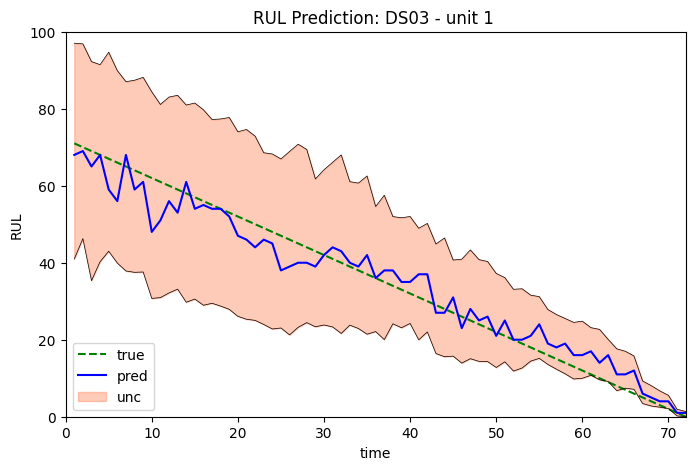

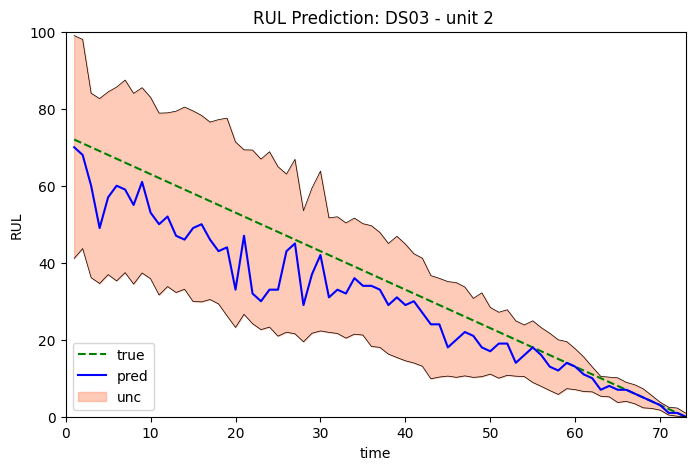

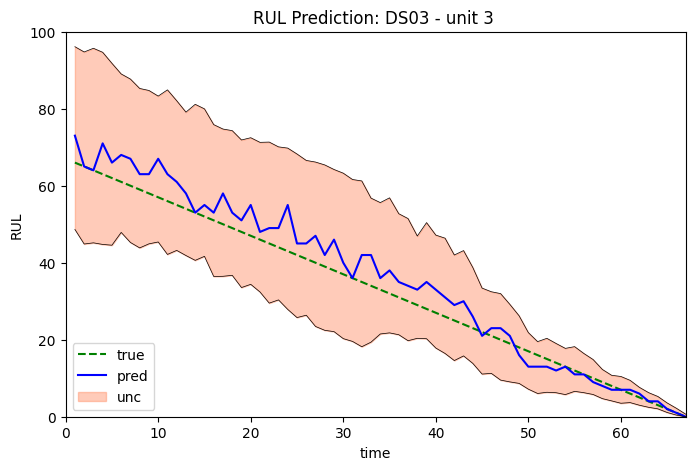

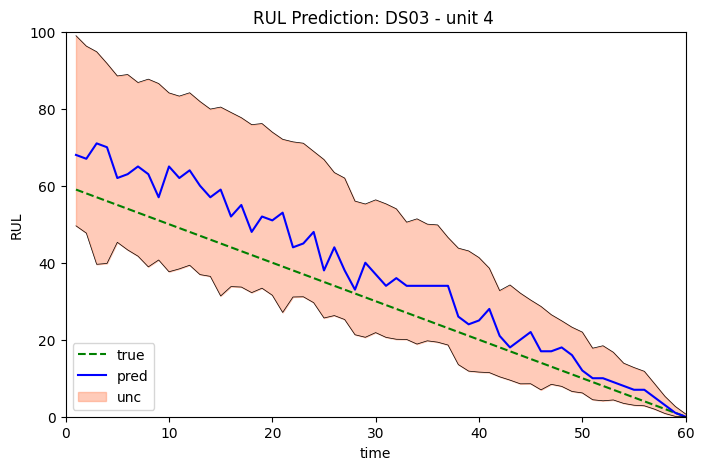

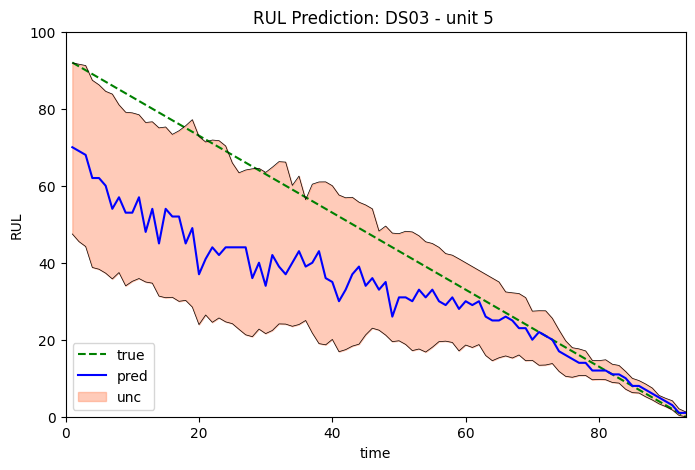

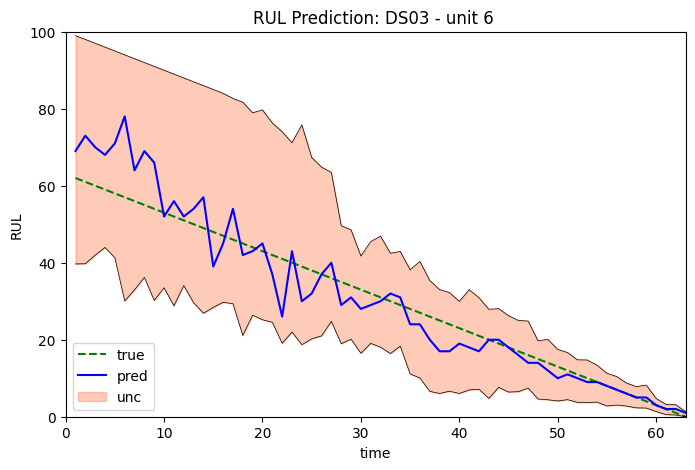

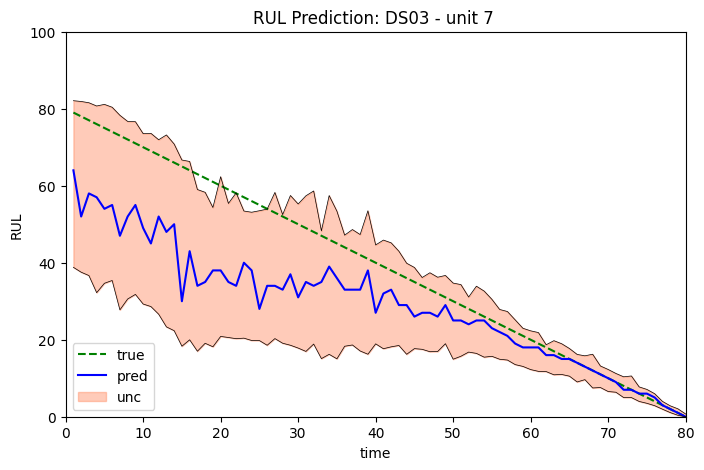

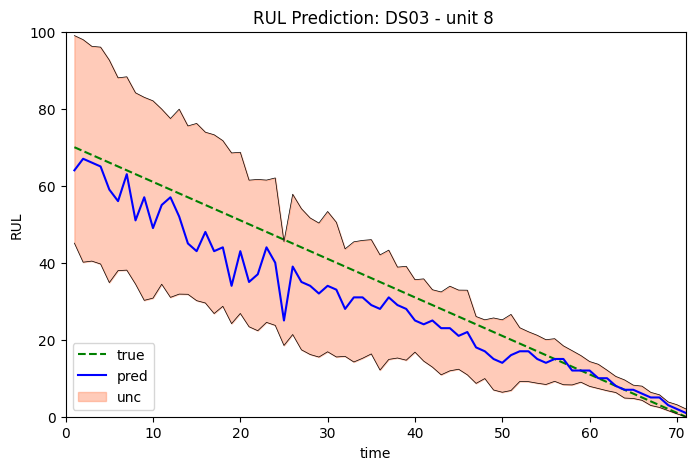

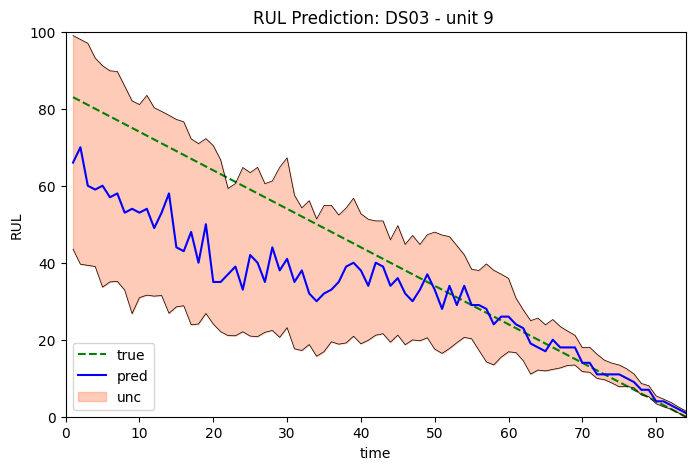

In [11]:
for unit in train_units:
	fig, ax = plt.subplots(figsize=(8, 5))
	df = preds_df[preds_df['unit']==unit]
	eol_time = df['time'].iloc[-1]
	plot_rul_from_dataframe(ax=ax, df=preds_df[preds_df['unit']==unit], t_max=eol_time, 
			title=f"RUL Prediction: {DATA_NAME} - unit {unit} ")
	fig.savefig(PRED_DIR / "rul_train_video.png")